In [15]:
# load data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("ForeignGifts_edu.csv")
# avoiding scientific notation  
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [2]:
# describe differences between different classes of gift types
df.groupby("Gift Type").describe()

ID                                                       \
                   count       mean       std       min        25%        50%   
Gift Type                                                                       
Contract      17274.0000 14860.6754 8727.1597    2.0000  7895.5000 15892.5000   
Monetary Gift 10936.0000 12920.0299 6970.9501    1.0000  6925.7500 12179.5000   
Real Estate      11.0000 20888.8182 5664.7924 9246.0000 23418.5000 23421.0000   

                                         OPEID              ...  \
                     75%        max      count        mean  ...   
Gift Type                                                   ...   
Contract      22316.7500 28220.0000 17274.0000 264930.7398  ...   
Monetary Gift 18119.2500 28221.0000 10936.0000 223025.2743  ...   
Real Estate   23447.5000 23459.0000    11.0000 300081.8182  ...   

              Foreign Gift Received Date            Foreign Gift Amount  \
                                     75%        max               count   
Gift Type                                                                 
Contract                      43503.0000 44012.0000          17274.0000   
Monetary Gift                 43403.0000 43911.0000          10936.0000   
Real Estate                   43510.5000 43646.0000             11.0000   

                                                                              \
                      mean          std          min         25%         50%   
Gift Type                                                                      
Contract       625794.5138 3768216.8712 -537770.0000  13757.5000 110000.0000   
Monetary Gift  528150.4355 2086487.1164       1.0000    250.0000  50000.0000   
Real Estate   1335265.4545 1412070.5728   39456.0000 370574.5000 667555.0000   

                                          
                       75%           max  
Gift Type                                 
Contract       366000.0000 99999999.0000  
Monetary Gift  400000.0000 48842186.0000  
Real Estate   2121736.0000  4312000.0000  

[3 rows x 32 columns]

There are three classes of Gift Type: Contract, Monetary Gift, and Real Estate. 

In [3]:
# which country gives the most money in total?
df.columns
df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head()

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
Name: Foreign Gift Amount, dtype: int64

Qatar gives the most money in total.

In [4]:
df.groupby("Country of Giftor").value_counts().head()

Country of Giftor  ID     OPEID   Institution Name                            City       State  Foreign Gift Received Date  Foreign Gift Amount  Gift Type      Giftor Name                        
AFGHANISTAN        12494  177500  University of Illinois at Urbana-Champaign  Champaign  IL     41799                       378900               Monetary Gift  Council for the Develop of Social      1
                   12495  177500  University of Illinois at Urbana-Champaign  Champaign  IL     41814                       1225689              Contract       Ministry of Health of Rwanda           1
                   22743  310000  Ohio University                             Athens     OH     43298                       121098               Contract       Mn Pub Wrks Islamic Rep Afghanistan    1
                   22745  310000  Ohio University                             Athens     OH     43361                       224000               Contract       Mn Pub Wrks Islamic Rep Afghanistan    1


Afghanistan initiates the most gifts by count. 

In [5]:
country_totals = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
grand_total = df["Foreign Gift Amount"].sum()

country_pct = (country_totals / grand_total * 100).sort_values(ascending=False)
print(country_pct.head(10))

Country of Giftor
QATAR          16.3021
ENGLAND         8.8245
CHINA           7.4573
SAUDI ARABIA    6.4167
BERMUDA         5.4191
CANADA          5.4104
HONG KONG       5.3456
JAPAN           3.9514
SWITZERLAND     3.7342
INDIA           3.2502
Name: Foreign Gift Amount, dtype: float64


In [6]:
df.groupby("Country of Giftor")['Foreign Gift Amount'].mean().sort_values(ascending=False).head()

Country of Giftor
BERMUDA   7688837.3675
ECUADOR   3985140.2857
QATAR     3905109.4791
ANTIGUA   3435545.0000
JERSEY    3064588.8333
Name: Foreign Gift Amount, dtype: float64

Bermuda gives the largest gifts on average.

In [7]:
df.columns

Index(['ID', 'OPEID', 'Institution Name', 'City', 'State',
       'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type',
       'Country of Giftor', 'Giftor Name'],
      dtype='str')

In [8]:
df.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head()

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
Name: Foreign Gift Amount, dtype: int64

Carnegie Mellon University receives the most money in total.

In [ ]:
gift_counts = (
    df.groupby("Institution Name").size().nlargest(20).reset_index(name='Gift Count')
)

,Institution Name,Gift Count
0,"University of California, Los Angeles",3916
1,California Institute of Technology,2502
2,Columbia University in the City of New York,1127
3,Ohio State University (The),1014
4,Johns Hopkins University,899
5,University of Michigan - Ann Arbor,715
6,Stanford University,668
7,Cornell University,653
8,University of Pennsylvania,625
9,Massachusetts Institute of Technology,582


University of California, Los Angeles receives the greatest number of gifts by count. 

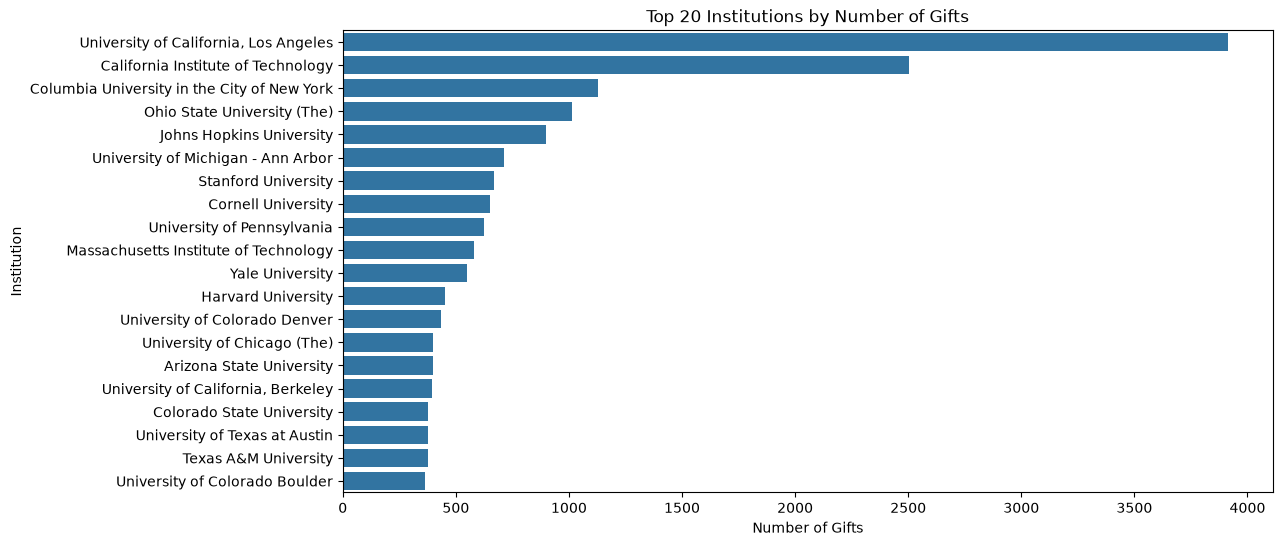

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data = gift_counts,
    x = 'Gift Count',
    y = 'Institution Name'
)
plt.xlabel('Number of Gifts')
plt.ylabel('Institution')
plt.title('Top 20 Institutions by Number of Gifts')
plt.show()

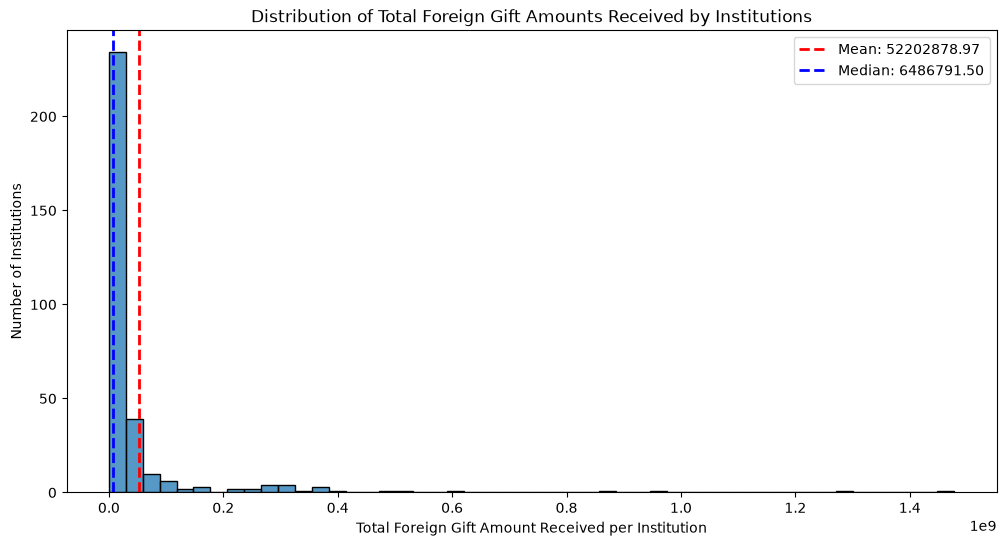

In [ ]:
university_totals = df.groupby("Institution Name")["Foreign Gift Amount"].sum()

mean_amt = university_totals.mean()
median_amt = university_totals.median()


plt.figure(figsize=(12, 6))
sns.histplot(university_totals, bins=50)
plt.axvline(mean_amt, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_amt:.2f}')
plt.axvline(median_amt, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_amt:.2f}')
plt.xlabel('Total Foreign Gift Amount Received per Institution')
plt.ylabel('Number of Institutions')
plt.title('Distribution of Total Foreign Gift Amounts Received by Institutions')
plt.legend()
plt.show()

For institutions in which the mean gift is greater than the median, there is right-skew. Large donations are pulling up the average, but the median is unaffected by these outliers.

In [11]:
df.groupby(["Country of Giftor", "Institution Name"])["Foreign Gift Amount"].sum().sort_values(ascending=False).head()

Country of Giftor  Institution Name          
QATAR              Cornell University            1018473315
BERMUDA            Carnegie Mellon University     750000000
QATAR              Texas A&M University           504099350
                   Carnegie Mellon University     425410702
                   Georgetown University          327128310
Name: Foreign Gift Amount, dtype: int64

The largest flow of a single country to a single instution is between Qatar and Cornell University. 

In [13]:
df.groupby(['Giftor Name'])['Foreign Gift Amount'].sum().sort_values(ascending=False).head()

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
Name: Foreign Gift Amount, dtype: int64

The top giftors to US academic institutions are almost entirely Qatari: Qatar Foundation ($1.17B), Qatar Foundation/Qatar National Research Fund ($796M), and Qatar Foundation for Education ($374M) are the three largest named giftors, together accounting for over $2.3B — consistent with Qatar's dominance in the country-level totals above. Saudi Arabian Cultural Mission rounds out the top five ($275M). "Anonymous" is the fourth-largest giftor ($339M), which is worth flagging since it can't be pursued or analyzed as an actual prospect.

In [ ]:
# crosstab
crosstab = pd.crosstab(
    index=df['Country of Giftor'],
    columns=df['Institution Name'],
    values=df['Foreign Gift Amount'],
    aggfunc='sum'
)
crosstab.head()

# .stack() to collaps the NaNs and show just country institution pairs with data
crosstab.stack().sort_values(ascending=False).head(10)


Country of Giftor     Institution Name              
QATAR                 Cornell University               1018473315.0000
BERMUDA               Carnegie Mellon University        750000000.0000
QATAR                 Texas A&M University              504099350.0000
                      Carnegie Mellon University        425410702.0000
                      Georgetown University             327128310.0000
                      Northwestern University           311148564.0000
CANADA                Brigham Young University          259927758.0000
UNITED ARAB EMIRATES  University of Colorado Boulder    219734835.0000
ENGLAND               Harvard University                188328288.0000
HONG KONG             Yale University                   161131218.0000
dtype: float64

## Flow of information using alluvial plots

The crosstab above shows the individual country-institution totals, but it's hard to see the overall pattern of concentration from a table. An alluvial (Sankey) diagram makes the biggest flows visible at a glance.

In [ ]:
import plotly.graph_objects as go

giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, recipi])[flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = flows[giftor].tolist() + flows[recipi].tolist()
labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels, pad=15, thickness=15),
        link=dict(
            source=flows[giftor].map(labels.index),
            target=flows[recipi].map(labels.index),
            value=flows[flow]
        )
    )
)
fig.update_layout(title_text="Top 25 Country → Institution Foreign Gift Flows", font_size=10)
fig.show()

Qatar's flows into Cornell, Texas A&M, Carnegie Mellon, Georgetown, and Northwestern dominate the diagram, alongside Bermuda's single large flow into Carnegie Mellon. The diagram makes the same point as Question 7 visually: the largest dollar flows in this dataset are concentrated in a small number of country-institution pairs rather than spread evenly.

### Bonus: flow of individual giftors to institutions

The country-level view above hides *which specific giftor* within a country is driving the flow. Repeating the diagram at the `Giftor Name` level shows that.

In [ ]:
giftor2 = 'Giftor Name'
N2 = 25

flows2 = (
    df.dropna(subset=[giftor2])
      .groupby([giftor2, recipi])[flow]
      .sum()
      .nlargest(N2)
      .reset_index()
)

labels2 = flows2[giftor2].tolist() + flows2[recipi].tolist()
labels2 = list(dict.fromkeys(labels2))

fig2 = go.Figure(
    go.Sankey(
        node=dict(label=labels2, pad=15, thickness=15),
        link=dict(
            source=flows2[giftor2].map(labels2.index),
            target=flows2[recipi].map(labels2.index),
            value=flows2[flow]
        )
    )
)
fig2.update_layout(title_text="Bonus: Top 25 Giftor → Institution Foreign Gift Flows", font_size=10)
fig2.show()